In [10]:
from AutoencoderAPI.pytorchDataloader import pytorchDataloader
from AutoencoderAPI.recurentTriplet import recurentTriplet
from AutoencoderAPI.fileBatch import fileBatch
from AutoencoderAPI.transformer import transformer
from AutoencoderAPI.utils.plot import load_run_results, load_sweep_results
from AutoencoderAPI.sweep import sweep

### Configuration

#### Triplet config

In [11]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/NIST PIKA 2 (4096)",
        'path_save'                : 'Autoencoder Log/',
        'input_dimension'          : 4096, 
        },
'network' : {
        'activation_list'          : ['GELU', 'GELU', 'PReLU', 'GELU', 'GELU'],
        'layer_list'               : [200, 100, 50, 1, 50, 100, 200],
        'layer_number'             : 4,
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'TripletMSE', 
        'alpha'                    : 0.002,
        'epochs'                   : 10,
        'skip_elements'            : 1,
        'learning_rate'            : 1e-6
        }
}

#### MSE config

In [12]:
run_config_MSE = {
'files' : {
        'dataset'                  : "Datasets/Oxford train",
        'path_save'                : 'Autoencoder Log/',
        'input_dimension'          : 496
        },
'network' : {
        'activation_list'          : ['GELU', 'GELU', 'PReLU', 'GELU', 'GELU'],
        'layer_list'               : [200, 100, 50, 1, 50, 100, 200],
        'layer_number'             : 6,
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss', 
        'k-fold'                   : 2,
        'batch_number'             : 1,
        'epochs'                   : 4,
        'skip_elements'            : 1,
        'learning_rate'            : 1e-4
        }
}

#### Transformer config

In [13]:
run_config_Transformer = {
'files' : {
        'dataset'                  : "Datasets/NIST (250)",
        'path_save'                : 'Autoencoder Log/',
        'input_dimension'          : 250
        },
'network' : {
        'nhead'                    : 250,
        'dropout'                  : 0.1,
        'sequence_len'             : 1       # 
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss',
        'epochs'                   : 6,
        'learning_rate'            : 1e-6
        }
}

### Run

In [14]:
func = recurentTriplet()
#func = fileBatch()
#func = transformer()
func.run(run_config_Triplet)

Epoch MSE:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

  0%|          | 0/2048 [00:00<?, ?it/s]

Epoch Triplet:   0%|          | 0/10 [00:00<?, ?it/s]

Size of training set :  2674
Optimal number of cluster :  20
Size of training set :  3392
Optimal number of cluster :  15
Size of training set :  4852
Optimal number of cluster :  14
Size of training set :  6284
Optimal number of cluster :  9
Size of training set :  7645
Optimal number of cluster :  9
Size of training set :  8093
Optimal number of cluster :  10
Size of training set :  11033
Optimal number of cluster :  14
Size of training set :  12441
Optimal number of cluster :  13
Size of training set :  14727
Optimal number of cluster :  12
Size of training set :  14727
Optimal number of cluster :  7


### Sweep

In [15]:
sweep_config = {
    'sweep_name'   : None,
    'search_param' : [('network','alpha'),('network','epochs')],
    'epochs'                   : [2,3,4,5,6,7,8],
    'learning_rate'            : [1e-3, 1e-4, 1e-5, 1e-6, 1e-7],
    'alpha'                    : [1e2, 1e1, 1e-0, 1e-1, 1e-2, 1e-3, 1e-4],
    'activation_possibilty'    : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                    'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                    'Mish', 'Softplus', 'Softsign', 'Tanh'],
    'layer_size_possibility'   : [5,50,75,100,200]
}

In [16]:
#exp = sweep()
#exp.grid_search("Transformer 1", run_config_Transformer, sweep_config)

### Load Run

Clusters:   0%|          | 0/8 [00:00<?, ?it/s]

Optimal number of clusters : 4
Optimal Silhouette score :  0.79611695


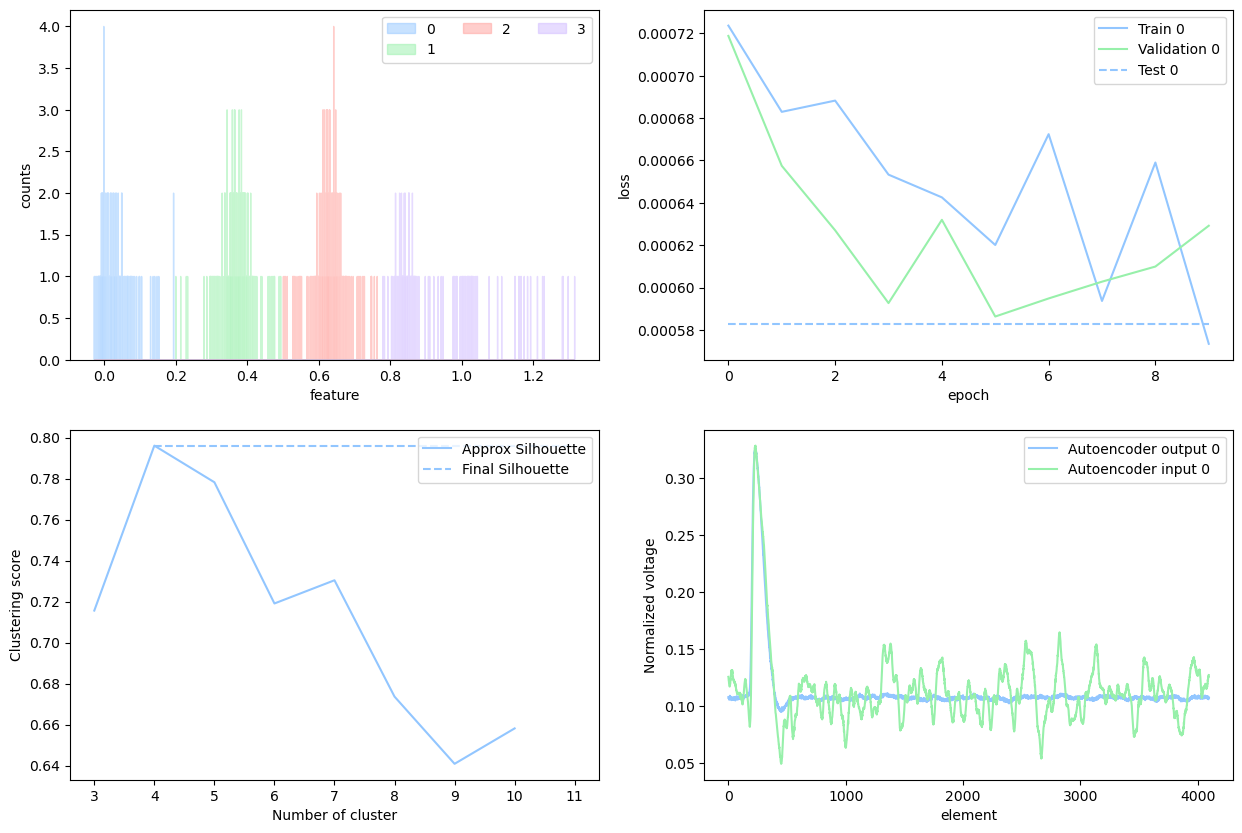

In [17]:
load_run_results("Autoencoder Log/run-2023-09-14-08-06", 3, 10)

### Load Sweep

In [18]:
#load_sweep_results("TripletMSE 6", ["alpha", "epochs"])